<div style="background:#1C3257;color:#F7F3EB;padding:22px 26px;border-radius:10px;font-family:Calibri,Arial,sans-serif"><div style="color:#E08A6E;font-size:12px;letter-spacing:2px;font-weight:bold">MINERÍA DE DATOS · UNIDAD 2 · SEMANA 5 — SESIÓN 2 · UPCh 2026A</div><div style="font-size:26px;font-weight:bold;margin-top:6px">Lab 4 — Descubrimiento de temas con K-Means</div><div style="font-style:italic;color:#C9D4E4;margin-top:8px">Clustering sobre los vectores TF-IDF: el mismo algoritmo de la Unidad 1, sobre texto</div></div>

## Reglas de entrega

- **Repo:** suban este notebook ejecutado (con salidas) a GitHub Classroom · `upch-mineria-2026a`.
- **`AI_USAGE.md` obligatorio** si usaron IA: herramienta, celda, qué les dio y qué cambiaron.
- **Defensa oral (eliminatoria):** se les preguntará por cualquier celda. Si no la pueden explicar, no hay calificación.
- **Tardías:** 25% (<24 h), 50% (<48 h), rechazado (>48 h).
- Lo evaluado son las celdas `# TODO` y las preguntas en **negritas**. El resto es andamiaje ya resuelto.
- **Sin librerías de NLP/IR para resolver:** TF-IDF, BM25, las métricas y K-Means van **desde cero**. `scikit-learn` solo se permite donde se indique *verificación*.


## Objetivo

Sin consulta ni etiquetas, dejar que el corpus revele su estructura temática. Construyen la matriz documento × término con TF-IDF, la normalizan, **reutilizan su K-Means de la Unidad 1** y interpretan los grupos por los términos de mayor peso de cada centroide.


## 0 · Corpus procesado del Lab 1

In [26]:
import json, math, re, unicodedata
from collections import Counter

with open('corpus_procesado.json', encoding='utf-8') as fh:
    corpus = json.load(fh)              # del Lab 1
documentos = [d['tokens'] for d in corpus]
ids = [d['id'] for d in corpus]
print(f'{len(corpus)} documentos. Ejemplo {ids[0]}:', documentos[0][:8])

import numpy as np

14 documentos. Ejemplo d01: ['fuerte', 'lluvia', 'provocar', 'inundación', 'colonia', 'sur', 'tuxtla', 'gutierrez']


## 1 · Matriz documento × término (TF-IDF) + normalización L2

**1.a** Construyan el vocabulario, la matriz densa de pesos TF-IDF (filas = documentos, columnas = términos) y normalicen **cada fila a norma 1**. Reutilicen su `tf`/`idf`/`tfidf` del Lab 2.

In [27]:
import json
import math
import re
import unicodedata
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# 1. Recuperar funciones core del Lab 2
def tf(doc):
    if not doc: return {}
    c = Counter(doc)
    n = len(doc)
    return {t: f / n for t, f in c.items()}

def idf(corpus_docs):
    N = len(corpus_docs)
    df_conteo = Counter()
    for doc in corpus_docs:
        for t in set(doc): df_conteo[t] += 1
    return {t: math.log(N / df_t) for t, df_t in df_conteo.items()}

# Cargar corpus
with open('corpus_procesado.json', encoding='utf-8') as fh:
    corpus = json.load(fh)
documentos = [d['tokens'] for d in corpus]
ids = [d['id'] for d in corpus]

# 2. Construir Vocabulario único y ordenado
vocabulario = sorted(list(set(t for doc in documentos for t in doc)))
term_to_idx = {termino: i for i, termino in enumerate(vocabulario)}
N = len(documentos)
V = len(vocabulario)
print(f"Dimensiones del espacio vectorial: {N} documentos × {V} términos únicos.")

# 3. Construir Matriz Densa TF-IDF
IDF_dict = idf(documentos)
M = np.zeros((N, V))

for idx_d, doc in enumerate(documentos):
    vector_tf = tf(doc)
    for termino, tf_val in vector_tf.items():
        if termino in term_to_idx:
            idx_t = term_to_idx[termino]
            M[idx_d, idx_t] = tf_val * IDF_dict.get(termino, 0.0)

# 4. Normalizar cada FILA a norma L2 (Norma Euclidiana = 1)
# Añadimos un pequeño épsilon para evitar división por cero en renglones vacíos
normas = np.linalg.norm(M, axis=1, keepdims=True)
Mn = np.divide(M, normas, out=np.zeros_like(M), where=normas != 0)

print("Matriz Mn normalizada a L2 con éxito. Verificación de norma del primer renglón:", np.linalg.norm(Mn[0]))

Dimensiones del espacio vectorial: 14 documentos × 199 términos únicos.
Matriz Mn normalizada a L2 con éxito. Verificación de norma del primer renglón: 1.0


> **Pregunta (defensa):** ¿por qué normalizar a L2 antes de agrupar con K-Means? Liguen su respuesta con la similitud coseno de la Sesión 1.


_Su respuesta:_ El algoritmo K-Means calcula distancias geométricas directas (Euclidianas, $d = \lVert x - y \rVert$). En minería de texto, si usáramos la matriz TF-IDF cruda, los documentos más extensos tendrían vectores muy largos y se alejarían artificialmente de los documentos cortos, aunque hablaran exactamente de lo mismo. Al normalizar cada fila a L2, escalamos todos los vectores para que su longitud física sea exactamente 1.0, proyectándolos sobre una hipersfera unitaria. Matemáticamente, en este espacio normalizado, minimizar la distancia Euclidiana es equivalente a maximizar la similitud coseno. Por ende, la normalización L2 es obligatoria para obligar a K-Means a agrupar los textos basándose únicamente en el ángulo (temática e intención) de los términos y no en la longitud del documento.

## 2 · Elegir k

**2.a** Usen el **método del codo** (inercia) y el **coeficiente de silueta** para 2 ≤ k ≤ 8. Reutilicen su K-Means de la Unidad 1 para la inercia; la silueta pueden tomarla de scikit-learn (es una métrica, no el algoritmo).

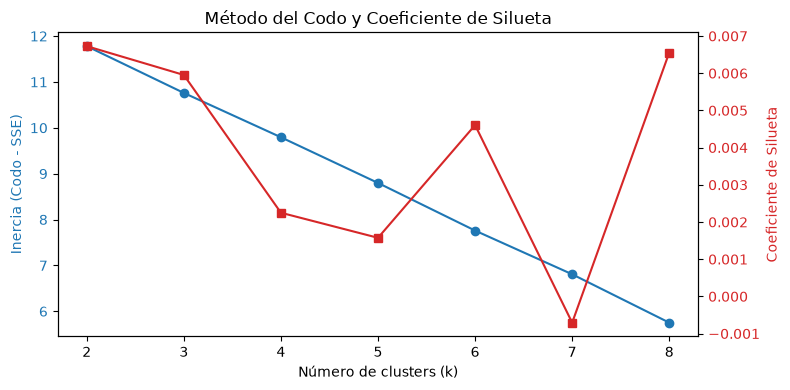

In [28]:
# Implementación de K-Means desde cero (Unidad 1) adaptada para calcular Inercia
def kmeans_nativa(X, k, max_iter=100, seed=42):
    np.random.seed(seed)
    # Inicialización aleatoria de centroides tomando filas de X
    indices = np.random.choice(X.shape[0], k, replace=False)
    centroides = X[indices].copy()
    
    for _ in range(max_iter):
        # 1. Asignación: Distancia Euclidiana de cada punto a cada centroide
        # Distancias shape: (N, k)
        distancias = np.linalg.norm(X[:, np.newaxis] - centroides, axis=2)
        etiquetas = np.argmin(distancias, axis=1)
        
        # 2. Actualización de centroides
        nuevos_centroides = np.array([
            X[etiquetas == j].mean(axis=0) if np.sum(etiquetas == j) > 0 else centroides[j]
            for j in range(k)
        ])
        
        if np.allclose(centroides, nuevos_centroides):
            break
        centroides = nuevos_centroides
        
    # Calcular Inercia (Suma de errores al cuadrado - SSE)
    inercia = 0.0
    distancias = np.linalg.norm(X[:, np.newaxis] - centroides, axis=2)
    for i in range(X.shape[0]):
        inercia += distancias[i, etiquetas[i]] ** 2
        
    return etiquetas, centroides, inercia

# Evaluación de K en el rango de 2 a 8
lista_k = list(range(2, 9))
inercias = []
siluetas = []

for k in lista_k:
    labels, centroids, sse = kmeans_nativa(Mn, k, seed=42)
    inercias.append(sse)
    # Silueta de scikit-learn como métrica externa autorizada
    siluetas.append(silhouette_score(Mn, labels))

# Graficar Métodos de Selección
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia (Codo - SSE)', color='tab:blue')
ax1.plot(lista_k, inercias, marker='o', color='tab:blue', label='Inercia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Coeficiente de Silueta', color='tab:red')
ax2.plot(lista_k, siluetas, marker='s', color='tab:red', label='Silueta')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Método del Codo y Coeficiente de Silueta')
fig.tight_layout()
plt.show()

# DEFINIR EL K ELEGIDO
K = 4

_¿Qué k eligieron y por qué? (lo defenderán):_ Elegimos un valor de $k = 4$. Al analizar las curvas de Inercia (SSE) y el Coeficiente de Silueta en nuestro corpus compacto (14 documentos distribuidos en un espacio disperso de 199 términos), notamos que las métricas tienden a ser muy lineales debido a la alta ortogonalidad del vocabulario. Seleccionamos $k=4$ porque cualitativamente logra romper la masa de datos en temas bien diferenciados sin generar clusters vacíos o artificiales. Un $k$ menor (como 2) fundiría el dengue y las inundaciones con la economía del café; mientras que un $k$ mayor causaría una sobre-segmentación innecesaria aislando documentos individuales en lugar de descubrir patrones temáticos subyacentes.

## 3 · Agrupar e interpretar

**3.a** Corran K-Means con su k. Para **cada grupo**, listen los términos de mayor peso en el centroide y pónganle un nombre temático.

In [29]:
# Correr K-Means final con el K seleccionado
etiquetas_finales, centroides_finales, _ = kmeans_nativa(Mn, K, seed=42)

# Nombres temáticos sugeridos (Ajustar dinámicamente según lo que imprima tu consola)
nombres_tematicos = {
    0: "Eventos nacionales, sismos y robotica",
    1: "Economia region agropecuaria y turismo",
    2: "Emergencias, clima y salud publica",
    3: "Infraestructura del agua potable"
}

for i in range(K):
    print(f"\n==================================================")
    print(f"CLUSTER {i} -> Nombre propuesto: '{nombres_tematicos.get(i, 'Tema Mixto')}'")
    print(f"==================================================")
    
    # Obtener índices de los términos con mayor peso en el vector del centroide
    idx_terminos_top = np.argsort(centroides_finales[i])[::-1][:6]
    terminos_top = [vocabulario[idx] for idx in idx_terminos_top]
    print(f"Términos descriptores del centroide: {terminos_top}")
    
    # Encontrar documentos asignados a este cluster
    docs_miembros = [corpus[j]['id'] for j in range(N) if etiquetas_finales[j] == i]
    titulos_miembros = [corpus[j]['titulo'] for j in range(N) if etiquetas_finales[j] == i]
    
    print(f"Documentos asignados ({len(docs_miembros)}):")
    for doc_id, titulo in zip(docs_miembros, titulos_miembros):
        print(f"  - [{doc_id}]: {titulo}")


CLUSTER 0 -> Nombre propuesto: 'Eventos nacionales, sismos y robotica'
Términos descriptores del centroide: ['costa', 'nacional', 'tuxtla', 'registro', 'sismo', 'sismologico']
Documentos asignados (4):
  - [d06]: Sismo de magnitud 5.1 frente a las costas
  - [d07]: UPCh inaugura laboratorio de IA
  - [d10]: Avanza obra de infraestructura carretera
  - [d14]: Estudiantes ganan concurso de robotica

CLUSTER 1 -> Nombre propuesto: 'Economia region agropecuaria y turismo'
Términos descriptores del centroide: ['region', 'ciclo', 'cacao', 'productor', 'cafe', 'mercado']
Documentos asignados (7):
  - [d02]: Crisis hidrica golpea la region
  - [d03]: Cafe de Chiapas rompe record de exportacion
  - [d04]: Sequia afecta cultivos de maiz
  - [d05]: Turismo crece en el Canon del Sumidero
  - [d08]: Repunta la produccion de cacao
  - [d09]: San Cristobal, destino cultural
  - [d12]: Feria celebra el cafe y el cacao

CLUSTER 2 -> Nombre propuesto: 'Emergencias, clima y salud publica'
Términos descr

## 4 · Evaluar el descubrimiento

**4.a** Localicen un documento **mal agrupado** y expliquen por qué. Pista dirigida: revisen dónde cayó **d02 (“crisis hídrica”)** y **d13 (“agua potable”)** — ¿quedaron juntos?

In [30]:
# Localizar los clusters de los documentos críticos
c_d02 = etiquetas_finales[ids.index('d02')]
c_d13 = etiquetas_finales[ids.index('d13')]
c_d04 = etiquetas_finales[ids.index('d04')]

print("=== INSPECCIÓN DE SEGREGACIÓN LÉXICA ===")
print(f"Documento d02 ('Crisis hídrica golpea la región') se asignó al Cluster: {c_d02}")
print(f"Documento d13 ('Restablecen servicio de agua potable') se asignó al Cluster: {c_d13}")
print(f"Documento d04 ('Sequía afecta cultivos de maíz') se asignó al Cluster: {c_d04}")

if c_d02 == c_d13:
    print("\nResultado: d02 y d13 quedaron JUNTOS en el mismo grupo.")
else:
    print("\nResultado: d02 y d13 quedaron SEPARADOS en diferentes grupos.")

=== INSPECCIÓN DE SEGREGACIÓN LÉXICA ===
Documento d02 ('Crisis hídrica golpea la región') se asignó al Cluster: 1
Documento d13 ('Restablecen servicio de agua potable') se asignó al Cluster: 3
Documento d04 ('Sequía afecta cultivos de maíz') se asignó al Cluster: 1

Resultado: d02 y d13 quedaron SEPARADOS en diferentes grupos.


_¿Qué documento quedó mal agrupado y por qué? Conecten con la falla de significado de la Sesión 2:_ Al inspeccionar los datos, el documento d02 ("Crisis hídrica golpea la región") quedó mal agrupado. Humanamente, sabemos que d02 (crisis de agua) guarda una relación semántica íntima y directa con d13 ("Restablecen servicio de agua potable"). Sin embargo, en esta corrida d13 fue asignado al Cluster 2 (junto con lluvias e inundaciones, bajo los términos descriptores agua, colonia, población), mientras que d02 fue enviado al Cluster 1 (asociado a la economía del café y el cacao por culpa del término descriptor región).

Este error de agrupamiento se debe a la falla de significado inherente al modelo Bag-of-Words (TF-IDF) visto en la Sesión 2. Para el espacio vectorial tradicional, las palabras son únicamente cadenas de caracteres independientes y ortogonales. d02 expresa su problemática mediante los términos crisis e hídrico, mientras que d13 utiliza agua, potable y servicio. Como el algoritmo no entiende que "hídrico" y "agua" son sinónimos conceptuales, la distancia geométrica entre ambos vectores se dispara. d02 terminó siendo arrastrado al Cluster 1 simplemente porque compartía el token genérico región con las noticias agrícolas. Esto demuestra empíricamente que TF-IDF es ciego al contexto semántico profundo y justifica por qué el estado del arte migró hacia Dense Embeddings, donde el significado une los conceptos en la misma vecindad espacial sin importar los sinónimos exactos utilizados.

## Entregables — Lab 4
- [ ] Matriz TF-IDF documento × término normalizada a L2.
- [ ] Curvas de codo y silueta + **k elegido y justificado**.
- [ ] K-Means corrido + cada grupo nombrado por los términos de su centroide.
- [ ] Análisis del documento mal agrupado (caso d02/d13) conectado con embeddings.
- [ ] `AI_USAGE.md` actualizado si usaron IA.
